In [14]:
pwd

'/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date'

In [3]:
import sys
import os

base_dir = "/Users/michaelfinch/CA1-interneuron-GLM"
sys.path.append(base_dir)
from GLM_regression import *
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

import utils as ut
import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
base_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/SliceTCA_MSE_Reconstruction"
file_name_template = "loss_dict_SST_latent_2_22_animal{i}"
SST_mean_2_22, SST_sem_2_22 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=10)

file_name_template = "loss_dict_SST_latent_22_42_animal{i}"
SST_mean_22_42, SST_sem_22_42 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=10)

file_name_template = "loss_dict_SST_latent_42_62_animal{i}"
sst_mean_42_64, sst_sem_42_64 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=10)


In [9]:
base_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/SliceTCA_MSE_Reconstruction"
file_name_template = "NDNF_latent_loss_2_22_animal_{i}"
NDNF_mean_2_22, NDNF_sem_2_22 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=4)

file_name_template = "loss_dict_NDNF_latent_22_42_animal{i}"
NDNF_mean_22_42, NDNF_sem_22_42 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=4)

file_name_template = "loss_dict_NDNF_latent_42_62_animal{i}"
animal_list = [0, 2, 3]
NDNF_mean_42_62, NDNF_sem_42_62 = get_data_by_animal_num(base_dir, file_name_template, animal_list=animal_list, num_animals=None)




In [11]:
base_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/SliceTCA_MSE_Reconstruction/EC_experiment"

EC_latent_means_2_22, EC_latent_sems_2_22 = cell_type_get_mean_sem(base_dir, start_num=2, end_num=22, cell_type="EC")

base_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/SliceTCA_MSE_Reconstruction"
EC_latent_means_22_42, EC_latent_sems_22_42 = cell_type_get_mean_sem(base_dir, start_num=22, end_num=43, cell_type="EC")

base_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/SliceTCA_MSE_Reconstruction/EC_experiment"
EC_latent_means_42_62, EC_latent_sems_42_62 = cell_type_get_mean_sem(base_dir, start_num=43, end_num=63, cell_type="EC")

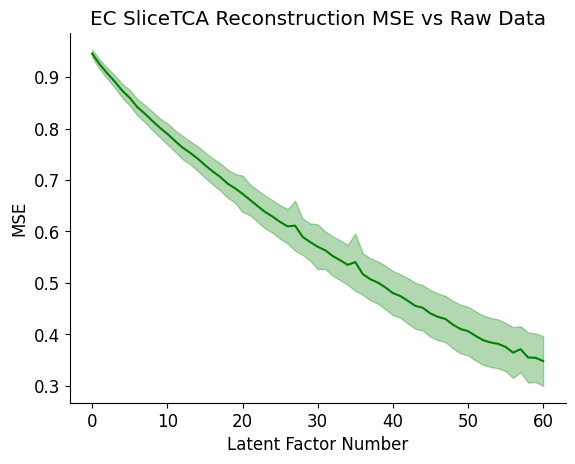

In [13]:
concatenated_EC_means = np.concatenate([EC_latent_means_2_22, EC_latent_means_22_42, EC_latent_means_42_62])
concatenated_EC_sem = np.concatenate([EC_latent_sems_2_22, EC_latent_sems_22_42, EC_latent_sems_42_62])

concatenated_SST_means = np.concatenate([SST_mean_2_22, SST_mean_22_42[:-1], sst_mean_42_64[:-1]])
concatenated_SST_sem = np.concatenate([SST_sem_2_22, SST_sem_22_42[:-1], sst_sem_42_64[:-1]])

concatenated_NDNF_means = np.concatenate([NDNF_mean_2_22, NDNF_mean_22_42[:-1], NDNF_mean_42_62[:-1]])
concatenated_NDNF_sem = np.concatenate([NDNF_sem_2_22, NDNF_sem_22_42[:-1], NDNF_sem_42_62[:-1]])

plt.plot(concatenated_EC_means, label="EC", color='g')
plt.fill_between(range(len(concatenated_EC_means)),
                 concatenated_EC_means + concatenated_EC_sem,
                 concatenated_EC_means - concatenated_EC_sem,
                 alpha=0.3, color='g')
# plt.plot(concatenated_SST_means, label="SST", color='b')
# plt.fill_between(range(len(concatenated_SST_means)),
#                  concatenated_SST_means + concatenated_SST_sem,
#                  concatenated_SST_means - concatenated_SST_sem,
#                  alpha=0.3, color='b')

# plt.plot(concatenated_NDNF_means, label="NDNF", color='orange')
# plt.fill_between(range(len(concatenated_NDNF_means)),
#                  concatenated_NDNF_means + concatenated_NDNF_sem,
#                  concatenated_NDNF_means - concatenated_NDNF_sem,
#                  alpha=0.3, color='orange')

plt.ylabel("MSE")
plt.xlabel("Latent Factor Number")
plt.title("EC SliceTCA Reconstruction MSE vs Raw Data")
plt.show()